Part B – Question 1
Random Forest

dataset

In [1]:
# Allowed libraries
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_diabetes
from sklearn.model_selection import train_test_split

data = load_diabetes()

X = data.data
y = data.target

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(X_train.shape, X_test.shape)

(353, 10) (89, 10)


Decision Tree

In [2]:
class DecisionTree:

    def __init__(self, max_depth=None, min_samples=5):
        self.max_depth = max_depth
        self.min_samples = min_samples
        self.tree = None

    def variance(self, y):
        return np.var(y)

    def best_split(self, X, y):

        best_feature = None
        best_threshold = None
        best_score = float("inf")

        n_features = X.shape[1]

        for feature in range(n_features):

            thresholds = np.unique(X[:, feature])

            for t in thresholds:

                left = y[X[:, feature] <= t]
                right = y[X[:, feature] > t]

                if len(left) == 0 or len(right) == 0:
                    continue

                score = (
                    len(left) * self.variance(left)
                    + len(right) * self.variance(right)
                )

                if score < best_score:
                    best_score = score
                    best_feature = feature
                    best_threshold = t

        return best_feature, best_threshold

    def build(self, X, y, depth=0):

        if (
            len(y) < self.min_samples
            or (self.max_depth is not None and depth >= self.max_depth)
        ):
            return np.mean(y)

        feature, threshold = self.best_split(X, y)

        if feature is None:
            return np.mean(y)

        left_mask = X[:, feature] <= threshold
        right_mask = X[:, feature] > threshold

        left_tree = self.build(X[left_mask], y[left_mask], depth + 1)
        right_tree = self.build(X[right_mask], y[right_mask], depth + 1)

        return (feature, threshold, left_tree, right_tree)

    def build_tree(self, X, y):
        self.tree = self.build(X, y)

    def predict_one(self, x, node):

        if not isinstance(node, tuple):
            return node

        feature, threshold, left, right = node

        if x[feature] <= threshold:
            return self.predict_one(x, left)
        else:
            return self.predict_one(x, right)

    def predict(self, X):

        preds = []
        for x in X:
            preds.append(self.predict_one(x, self.tree))

        return np.array(preds)

Train Single Decision Tree

In [3]:
tree = DecisionTree(max_depth=5)
tree.build_tree(X_train, y_train)

pred_tree = tree.predict(X_test)

mse_tree = np.mean((pred_tree - y_test) ** 2)

print("Decision Tree MSE:", mse_tree)

Decision Tree MSE: 3759.432005424214


Random Forest

In [4]:
class RandomForest:

    def __init__(self, n_trees=10, max_depth=5):
        self.n_trees = n_trees
        self.max_depth = max_depth
        self.trees = []

    def build_forest(self, X, y):

        n_samples = X.shape[0]

        for _ in range(self.n_trees):

            idx = np.random.choice(n_samples, n_samples, replace=True)

            X_sample = X[idx]
            y_sample = y[idx]

            tree = DecisionTree(max_depth=self.max_depth)

            tree.build_tree(X_sample, y_sample)

            self.trees.append(tree)

    def predict(self, X):

        preds = []

        for tree in self.trees:
            preds.append(tree.predict(X))

        preds = np.array(preds)

        return np.mean(preds, axis=0)

Train Random Forest

In [5]:
rf = RandomForest(n_trees=20, max_depth=6)

rf.build_forest(X_train, y_train)

pred_rf = rf.predict(X_test)

mse_rf = np.mean((pred_rf - y_test) ** 2)

print("Random Forest MSE:", mse_rf)

Random Forest MSE: 2827.3630996252573


Compare Performance

Decision Tree MSE: 3759.432005424214
Random Forest MSE: 2827.3630996252573


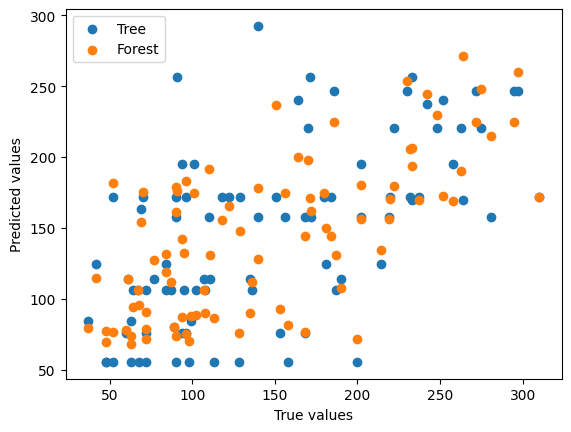

In [6]:
print("Decision Tree MSE:", mse_tree)
print("Random Forest MSE:", mse_rf)

plt.scatter(y_test, pred_tree, label="Tree")
plt.scatter(y_test, pred_rf, label="Forest")

plt.xlabel("True values")
plt.ylabel("Predicted values")

plt.legend()
plt.show()